In [2]:
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler 

Carga de datos

In [3]:
df_info_equipos = pd.read_csv('../output/equipos_info2.csv')

In [4]:
df_info_equipos.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,...,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Fallo,Numero_Fallos,Total_Registros,Probabilidad_Fallo
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,799,2020-02-03 06:00:00,Preventivo,404.72,37,Planta Oeste,0,120,330,0.363636
1,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,837,2020-02-04 20:00:00,Correctivo,7465.08,39,Planta Este,1,120,330,0.363636
2,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1344,2020-02-25 23:00:00,Correctivo,7577.35,40,Planta Norte,1,120,330,0.363636
3,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1836,2020-03-17 11:00:00,Correctivo,5227.75,17,Planta Oeste,1,120,330,0.363636
4,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,2103,2020-03-28 14:00:00,Preventivo,6879.63,16,Planta Oeste,0,120,330,0.363636


Hacemos copia para trabajar sobre ella

In [5]:
df_info_equipos_copia= df_info_equipos.copy()

In [6]:
df_info_equipos_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178007 entries, 0 to 178006
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    178007 non-null  int64  
 1   Tipo_Equipo                  178007 non-null  object 
 2   Fabricante                   178007 non-null  object 
 3   Modelo                       178007 non-null  object 
 4   Potencia_kW                  178007 non-null  float64
 5   Horas_Recomendadas_Revision  178007 non-null  int64  
 6   Frecuencia_Mto               178007 non-null  int64  
 7   Vida_Util                    178007 non-null  float64
 8   ID_Registro                  178007 non-null  int64  
 9   Fecha_x                      178007 non-null  object 
 10  Temperatura_C                178007 non-null  float64
 11  Vibracion_mm_s               178007 non-null  float64
 12  Horas_Operativas             178007 non-null  float64
 13 

In [7]:
df_info_equipos_copia.head()

,ID_Equipo,Tipo_Equipo,Fabricante,Modelo,Potencia_kW,Horas_Recomendadas_Revision,Frecuencia_Mto,Vida_Util,ID_Registro,Fecha_x,...,ID_Orden,Fecha_y,Tipo_Mantenimiento,Costo_Mantenimiento,Duracion_Horas,Ubicacion,Fallo,Numero_Fallos,Total_Registros,Probabilidad_Fallo
0,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,799,2020-02-03 06:00:00,Preventivo,404.72,37,Planta Oeste,0,120,330,0.363636
1,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,837,2020-02-04 20:00:00,Correctivo,7465.08,39,Planta Este,1,120,330,0.363636
2,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1344,2020-02-25 23:00:00,Correctivo,7577.35,40,Planta Norte,1,120,330,0.363636
3,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,1836,2020-03-17 11:00:00,Correctivo,5227.75,17,Planta Oeste,1,120,330,0.363636
4,1,Compresor,Siemens,Z300,3429.0,7725,22,870072.0,28,2020-01-02 03:00:00,...,2103,2020-03-28 14:00:00,Preventivo,6879.63,16,Planta Oeste,0,120,330,0.363636


In [8]:
# Convertir la columna 'fecha' a formato datetime 

df_info_equipos_copia['Fecha_y'] = pd.to_datetime(df_info_equipos_copia['Fecha_y'], format='%Y-%m-%d %H:%M:%S')

# Separar la fecha en día, mes y año 

df_info_equipos_copia['dia'] = df_info_equipos_copia['Fecha_y'].dt.day
df_info_equipos_copia['mes'] = df_info_equipos_copia['Fecha_y'].dt.month
df_info_equipos_copia['año'] = df_info_equipos_copia['Fecha_y'].dt.year

print(df_info_equipos_copia)

        ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
0               1   Compresor    Siemens   Z300       3429.0   
1               1   Compresor    Siemens   Z300       3429.0   
2               1   Compresor    Siemens   Z300       3429.0   
3               1   Compresor    Siemens   Z300       3429.0   
4               1   Compresor    Siemens   Z300       3429.0   
...           ...         ...        ...    ...          ...   
178002        499       Motor    Siemens   Y200       3155.0   
178003        499       Motor    Siemens   Y200       3155.0   
178004        499       Motor    Siemens   Y200       3155.0   
178005        499       Motor    Siemens   Y200       3155.0   
178006        499       Motor    Siemens   Y200       3155.0   

        Horas_Recomendadas_Revision  Frecuencia_Mto  Vida_Util  ID_Registro  \
0                              7725              22   870072.0           28   
1                              7725              22   870072.0           

In [9]:
df_info_equipos_copia.isnull().sum()


ID_Equipo                      0
Tipo_Equipo                    0
Fabricante                     0
Modelo                         0
Potencia_kW                    0
Horas_Recomendadas_Revision    0
Frecuencia_Mto                 0
Vida_Util                      0
ID_Registro                    0
Fecha_x                        0
Temperatura_C                  0
Vibracion_mm_s                 0
Horas_Operativas               0
ID_Orden                       0
Fecha_y                        0
Tipo_Mantenimiento             0
Costo_Mantenimiento            0
Duracion_Horas                 0
Ubicacion                      0
Fallo                          0
Numero_Fallos                  0
Total_Registros                0
Probabilidad_Fallo             0
dia                            0
mes                            0
año                            0
dtype: int64

In [ ]:
# Filtrar registros donde Tipo_Mantenimiento sea "Correctivo"
df_correctivo = df_info_equipos_copia[df_info_equipos_copia['Tipo_Mantenimiento'] == 'Correctivo']
 
# Ordenar los datos por ID_Equipo y mes
df_correctivo.sort_values(by=['ID_Equipo', 'mes'], inplace=True)
 
# Calcular la diferencia en meses entre mantenimientos correctivos
df_correctivo['Tpo_Fallo'] = df_correctivo['mes'].diff()  # Aquí asumimos que 'mes' ya está en formato numérico
 
# Agrupar por mes y ID_Equipo, calculando la media del tiempo de fallo
df_tpo_fallo_agrupado = df_correctivo.groupby(['mes', 'ID_Equipo'])['Tpo_Fallo'].mean().reset_index()

# Agregar la nueva columna Tpo_Fallo al DataFrame original
df_info_equipos_copia = pd.merge(df_info_equipos_copia, df_tpo_fallo_agrupado, how='left', on=['mes', 'ID_Equipo'])
 
df_info_equipos_copia.sample(5)

### SEPARACIÓN CATEGORICAS Y NUMÉRICAS

In [8]:
# Identificar variables numéricas y categóricas
num_cols = df_info_equipos_copia.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_info_equipos_copia.select_dtypes(include=['object']).columns.tolist()
 
print(f"Variables numéricas: {len(num_cols)}")
print(f"Variables categóricas: {len(cat_cols)}")

Variables numéricas: 16
Variables categóricas: 7


In [9]:
print(num_cols)

['ID_Equipo', 'Potencia_kW', 'Horas_Recomendadas_Revision', 'Frecuencia_Mto', 'Vida_Util', 'ID_Registro', 'Temperatura_C', 'Vibracion_mm_s', 'Horas_Operativas', 'ID_Orden', 'Costo_Mantenimiento', 'Duracion_Horas', 'Fallo', 'Numero_Fallos', 'Total_Registros', 'Probabilidad_Fallo']


In [10]:
print(cat_cols)

['Tipo_Equipo', 'Fabricante', 'Modelo', 'Fecha_x', 'Fecha_y', 'Tipo_Mantenimiento', 'Ubicacion']


### ENCODED

Pasamos las columnas categóricas a numéricas para futuro tratamiento a la hora de entrenar modelos

In [11]:
# Paso 2: Aplicar codificación LabelEncoder a las columnas categóricas
label_encoders = {}  # Diccionario para guardar cada encoder si lo necesitas luego
 
for col in cat_cols:
    le = LabelEncoder()
    df_info_equipos_copia[col + '_encoded'] = le.fit_transform(df_info_equipos_copia[col].astype(str))
    label_encoders[col] = le  # Guarda el encoder por si necesitás revertirlo o transformarlo en otro dataset
 
# (Opcional) Ver el nuevo DataFrame
print(df_info_equipos_copia.head())


   ID_Equipo Tipo_Equipo Fabricante Modelo  Potencia_kW  \
0          1   Compresor    Siemens   Z300       3429.0   
1          1   Compresor    Siemens   Z300       3429.0   
2          1   Compresor    Siemens   Z300       3429.0   
3          1   Compresor    Siemens   Z300       3429.0   
4          1   Compresor    Siemens   Z300       3429.0   

   Horas_Recomendadas_Revision  Frecuencia_Mto  Vida_Util  ID_Registro  \
0                         7725              22   870072.0           28   
1                         7725              22   870072.0           28   
2                         7725              22   870072.0           28   
3                         7725              22   870072.0           28   
4                         7725              22   870072.0           28   

               Fecha_x  ...  Numero_Fallos  Total_Registros  \
0  2020-01-02 03:00:00  ...            120              330   
1  2020-01-02 03:00:00  ...            120              330   
2  2020-01-

Comprobamos que las columnas ahora son numéricas. 

In [12]:
df_info_equipos_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178007 entries, 0 to 178006
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    178007 non-null  int64  
 1   Tipo_Equipo                  178007 non-null  object 
 2   Fabricante                   178007 non-null  object 
 3   Modelo                       178007 non-null  object 
 4   Potencia_kW                  178007 non-null  float64
 5   Horas_Recomendadas_Revision  178007 non-null  int64  
 6   Frecuencia_Mto               178007 non-null  int64  
 7   Vida_Util                    178007 non-null  float64
 8   ID_Registro                  178007 non-null  int64  
 9   Fecha_x                      178007 non-null  object 
 10  Temperatura_C                178007 non-null  float64
 11  Vibracion_mm_s               178007 non-null  float64
 12  Horas_Operativas             178007 non-null  float64
 13 

Creamos un dataframe con esas columnas numéricas. 

In [13]:
df_info_equpos_num= df_info_equipos_copia.select_dtypes(include=['int64', 'float64'])
df_info_equpos_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178007 entries, 0 to 178006
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID_Equipo                    178007 non-null  int64  
 1   Potencia_kW                  178007 non-null  float64
 2   Horas_Recomendadas_Revision  178007 non-null  int64  
 3   Frecuencia_Mto               178007 non-null  int64  
 4   Vida_Util                    178007 non-null  float64
 5   ID_Registro                  178007 non-null  int64  
 6   Temperatura_C                178007 non-null  float64
 7   Vibracion_mm_s               178007 non-null  float64
 8   Horas_Operativas             178007 non-null  float64
 9   ID_Orden                     178007 non-null  int64  
 10  Costo_Mantenimiento          178007 non-null  float64
 11  Duracion_Horas               178007 non-null  int64  
 12  Fallo                        178007 non-null  int64  
 13 

### IDENTIFICAR CONSTANTES

In [14]:
# Identificar las columnas constantes
columnas_constantes = [col 
                       for col in df_info_equpos_num.columns 
                        if df_info_equpos_num[col].nunique() == 1]

print("Columnas constantes:", columnas_constantes)


Columnas constantes: []


Analizamos columnas cuasiconstantes

In [15]:
# Umbral para definir "cuasiconstante" (por ejemplo, 99%)
umbral = 0.98

columnas_cuasiconstantes = [
    col for col in df_info_equpos_num.columns
    if df_info_equpos_num[col].value_counts(normalize=True).max() > umbral
]

print("Columnas cuasiconstantes:", columnas_cuasiconstantes)

Columnas cuasiconstantes: []


Se realiza el escalado de las variables

In [16]:
# Crear un scaler y ajustarlo a los datos
scaler = MinMaxScaler()
df_info_equipos_escalado = pd.DataFrame(scaler.fit_transform(df_info_equpos_num), columns=df_info_equpos_num.columns)

print(df_info_equipos_escalado.head())

   ID_Equipo  Potencia_kW  Horas_Recomendadas_Revision  Frecuencia_Mto  \
0        0.0     0.037456                     0.761262        0.541667   
1        0.0     0.037456                     0.761262        0.541667   
2        0.0     0.037456                     0.761262        0.541667   
3        0.0     0.037456                     0.761262        0.541667   
4        0.0     0.037456                     0.761262        0.541667   

   Vida_Util  ID_Registro  Temperatura_C  Vibracion_mm_s  Horas_Operativas  \
0   0.370028        0.003       0.437706        0.006303           0.80052   
1   0.370028        0.003       0.437706        0.006303           0.80052   
2   0.370028        0.003       0.437706        0.006303           0.80052   
3   0.370028        0.003       0.437706        0.006303           0.80052   
4   0.370028        0.003       0.437706        0.006303           0.80052   

   ID_Orden  ...  Numero_Fallos  Total_Registros  Probabilidad_Fallo  \
0  0.079808  .

###Estudiar correlaciones 

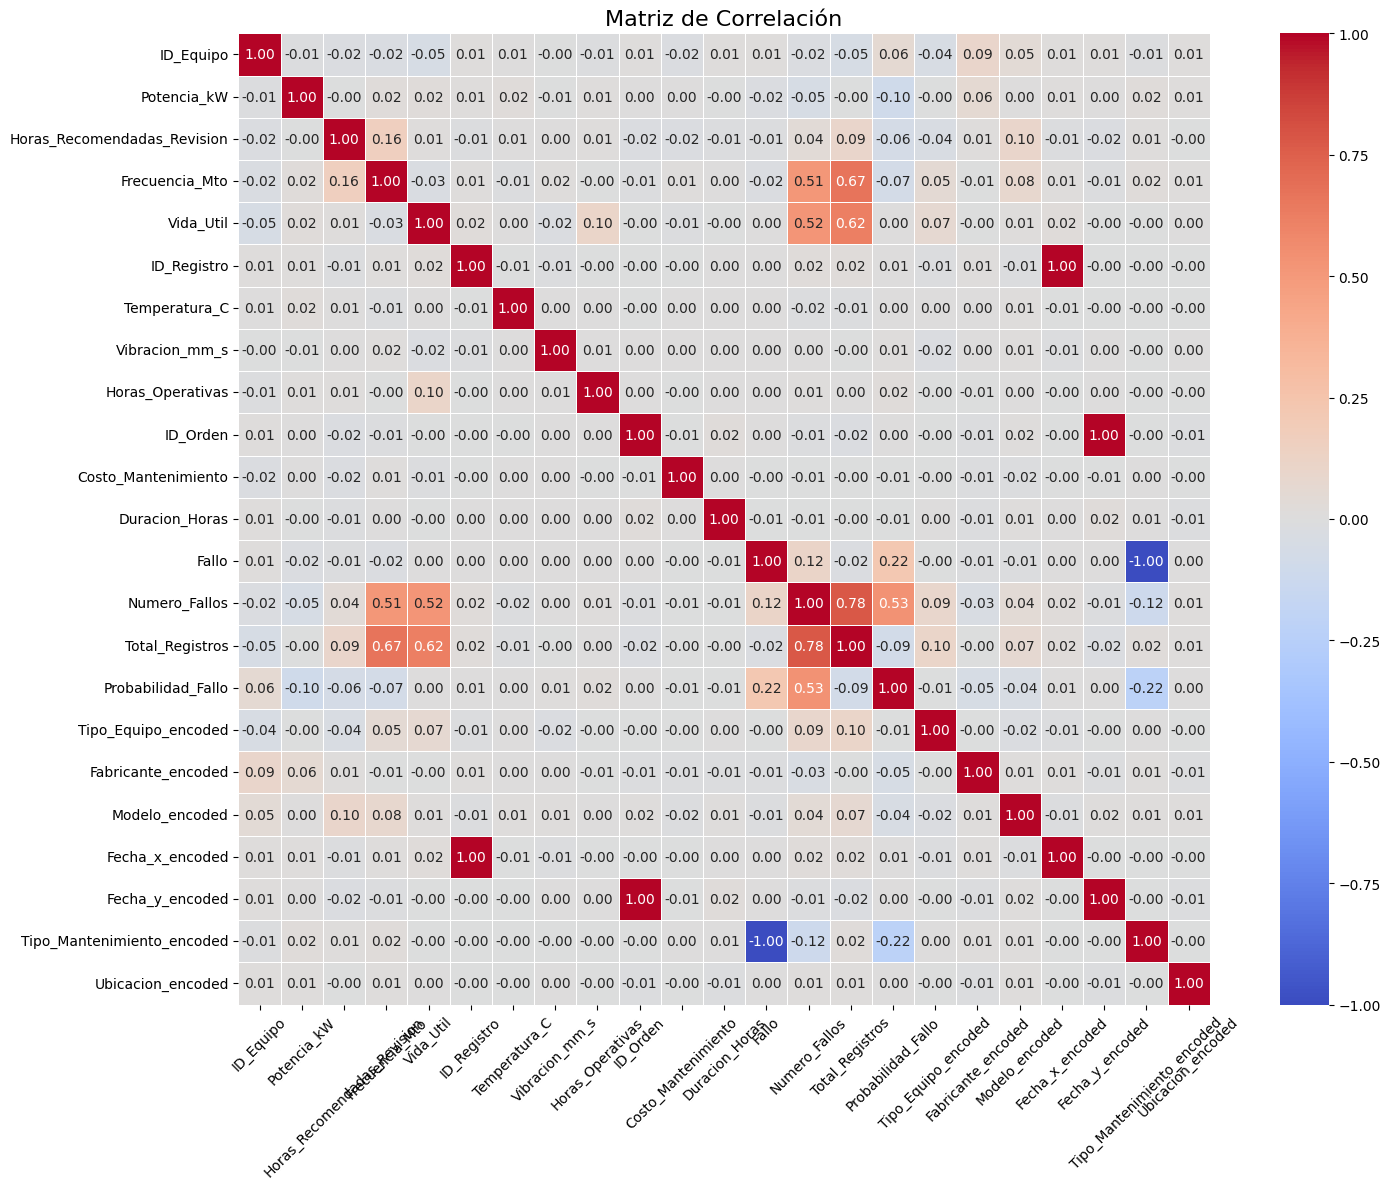

In [17]:
 
# Calcular la matriz de correlación
correlation_matrix = df_info_equipos_escalado.corr()
 
# Configurar tamaño del gráfico
plt.figure(figsize=(16, 12))
 
# Crear el heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
 
# Título del gráfico
plt.title("Matriz de Correlación", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
 
# Mostrar el gráfico
plt.show()

Podemos observar que las características que más información aportan para generar un modelo de predicción de fallos, serían: Numero_Fallos, Horas_Recomendadas_Revision, Vida_Util, Total_Registros, Temperatura_C, Vibracion_mm_s, Tipo_Mantenimiento_encoded.
Con esto, crearemos un nuevo dataframe para entrenar nuestros modelos. 

In [ ]:
# Seleccionar las columnas
columnas_a_eliminar = [
     'ID_Equipo',
    'ID_Registro',
    'ID_Orden',
    'Fecha_x_encoded',
    'Fecha_y_encoded',
    'Modelo_encoded',
    'Potencia_kW',
    'Horas_Operativas',
    'Costo_Mantenimiento',
    'Duracion_Horas',
    'Probabilidad_Fallo',
    'Tipo_Equipo_encoded',
    'Fabricante_encoded',
    'Ubicacion_encoded'
]
 
# Crear una copia del DataFrame original
df_equipos_best_info = df_info_equipos_escalado.copy()
 
# Eliminar columnas no útiles para el modelo
df_equipos_best_info.drop(columns=columnas_a_eliminar, inplace=True)
 
# Verificar el resultado
print("Columnas restantes:", df_equipos_best_info.columns.tolist())
print(df_equipos_best_info.head())
 

Columnas restantes: ['Horas_Recomendadas_Revision', 'Frecuencia_Mto', 'Vida_Util', 'Temperatura_C', 'Vibracion_mm_s', 'Fallo', 'Numero_Fallos', 'Total_Registros', 'Tipo_Mantenimiento_encoded']
   Horas_Recomendadas_Revision  Frecuencia_Mto  Vida_Util  Temperatura_C  \
0                     0.761262        0.541667   0.370028       0.437706   
1                     0.761262        0.541667   0.370028       0.437706   
2                     0.761262        0.541667   0.370028       0.437706   
3                     0.761262        0.541667   0.370028       0.437706   
4                     0.761262        0.541667   0.370028       0.437706   

   Vibracion_mm_s  Fallo  Numero_Fallos  Total_Registros  \
0        0.006303    0.0       0.205607          0.34375   
1        0.006303    1.0       0.205607          0.34375   
2        0.006303    1.0       0.205607          0.34375   
3        0.006303    1.0       0.205607          0.34375   
4        0.006303    0.0       0.205607          0

SEPARACIÓN EN TRAIN Y TEST

In [27]:
X_train, X_test, y_train, y_test = train_test_split(df_equipos_best_info, df_equipos_best_info.Fallo, test_size=0.3,
                                                    random_state=0)
X_train.shape, X_test.shape

((124604, 9), (53403, 9))

Una vez separado los datasets para entrenamiento y test, lanzamos a entrenar un modelo Random Forest, teniendo en cuenta que nuestro probelma es de Clasificación

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar el modelo
modelo_base = RandomForestClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

# Evaluar el modelo
accuracy = modelo_base.score(X_test, y_test)
print(f"Exactitud del modelo base: {accuracy:.2f}")

Exactitud del modelo base: 1.00


Viendo que el accuracy del modelo es 1, deducimos un sobreajuste del mismo. Los datos no reales, pueden generar este overfitting 
Continuamos probando con otros modelos.